In [9]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (LSTM, Dense, Input,
                                      Concatenate, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


In [10]:
# Load the ecommerce behaviour dataset

df = pd.read_csv('../data/retail.csv') 
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
print("Dataset Info:")
print("=" * 50)
df.info()

print("\nStatistical Description:")
print("=" * 50)
print(df.describe(include='all'))

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB

Statistical Description:
        Invoice StockCode                         Description      Quantity  \
count   1067371   1067371                             1062989  1.067371e+06   
unique    53628      5305                                5698           NaN   
top      537434    85123A  WHITE HANGING HEART T-LIGHT HOLDER           NaN   
freq       1350      5829                   

In [12]:
 # 3 — Data Cleaning

print("=== BEFORE CLEANING ===")
print(f"Total records   : {len(df):,}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

# 1. Drop missing Customer ID
print(f"\nMissing Customer ID: {df['Customer ID'].isnull().sum():,}")
df.dropna(subset=['Customer ID'], inplace=True)

# 2. Drop missing Description
df.dropna(subset=['Description'], inplace=True)

# 3. Remove cancelled invoices (start with 'C')
cancelled = df['Invoice'].astype(str).str.startswith('C')
print(f"Cancelled invoices removed: {cancelled.sum():,}")
df = df[~cancelled].copy()

# 4. Remove negative or zero Quantity
print(f"Negative/zero Quantity: {(df['Quantity'] <= 0).sum():,}")
df = df[df['Quantity'] > 0].copy()

# 5. Remove negative or zero Price
print(f"Negative/zero Price: {(df['Price'] <= 0).sum():,}")
df = df[df['Price'] > 0].copy()

# 6. Convert types
df['Customer ID']  = df['Customer ID'].astype(int)
df['InvoiceDate']  = pd.to_datetime(df['InvoiceDate'])

print("\n=== AFTER CLEANING ===")
print(f"Total records retained : {len(df):,}")
print(f"Unique customers       : {df['Customer ID'].nunique():,}")
print(f"Missing values         : {df.isnull().sum().sum()}")

=== BEFORE CLEANING ===
Total records   : 1,067,371

Missing values per column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing Customer ID: 243,007
Cancelled invoices removed: 18,744
Negative/zero Quantity: 0
Negative/zero Price: 71

=== AFTER CLEANING ===
Total records retained : 805,549
Unique customers       : 5,878
Missing values         : 0


In [13]:
# 4 — Feature Engineering

df['Revenue'] = df['Quantity'] * df['Price']
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# Transactional features
trans_df = df.groupby('Customer ID').agg(
    total_purchase_amount   = ('Revenue',      'sum'),
    num_purchases           = ('Invoice',      'nunique'),
    avg_order_value         = ('Revenue',      'mean'),
    total_items             = ('Quantity',     'sum'),
    recency_days            = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),
    first_purchase_gap_days = ('InvoiceDate',  lambda x: (x.max() - x.min()).days)
).reset_index()

# Behavioral features
beh_df = df.groupby('Customer ID').agg(
    sessions_per_user  = ('InvoiceDate', lambda x: x.dt.date.nunique()),
    category_diversity = ('StockCode',   'nunique'),
    total_views        = ('Quantity',    'sum')
).reset_index()

# Top category per customer
top_cat = (df.groupby(['Customer ID', 'StockCode'])
             .size().reset_index(name='freq')
             .sort_values('freq', ascending=False)
             .drop_duplicates('Customer ID')
             [['Customer ID', 'StockCode']]
             .rename(columns={'StockCode': 'top_category'}))

# Merge all
hybrid_df = trans_df.merge(beh_df,    on='Customer ID', how='inner')
hybrid_df = hybrid_df.merge(top_cat,  on='Customer ID', how='left')

hybrid_df['conversion_rate']     = (hybrid_df['num_purchases'] /
                                    (hybrid_df['sessions_per_user'] + 1))
hybrid_df['avg_items_per_order'] = (hybrid_df['total_items'] /
                                    (hybrid_df['num_purchases'] + 1))

print(f"\nHybrid feature matrix: {hybrid_df.shape}")
print(f"Unique customers      : {hybrid_df['Customer ID'].nunique():,}")
print(hybrid_df.head())

Reference date: 2011-12-10 12:50:00

Hybrid feature matrix: (5878, 13)
Unique customers      : 5,878
   Customer ID  total_purchase_amount  num_purchases  avg_order_value  \
0        12346               77556.46             12      2281.072353   
1        12347                5633.32              8        22.266087   
2        12348                2019.40              5        39.596078   
3        12349                4428.69              4        25.306800   
4        12350                 334.40              1        19.670588   

   total_items  recency_days  first_purchase_gap_days  sessions_per_user  \
0        74285           326                      400                  8   
1         3286             2                      402                  8   
2         2714            75                      362                  5   
3         1624            19                      570                  4   
4          197           310                        0                  1   

   

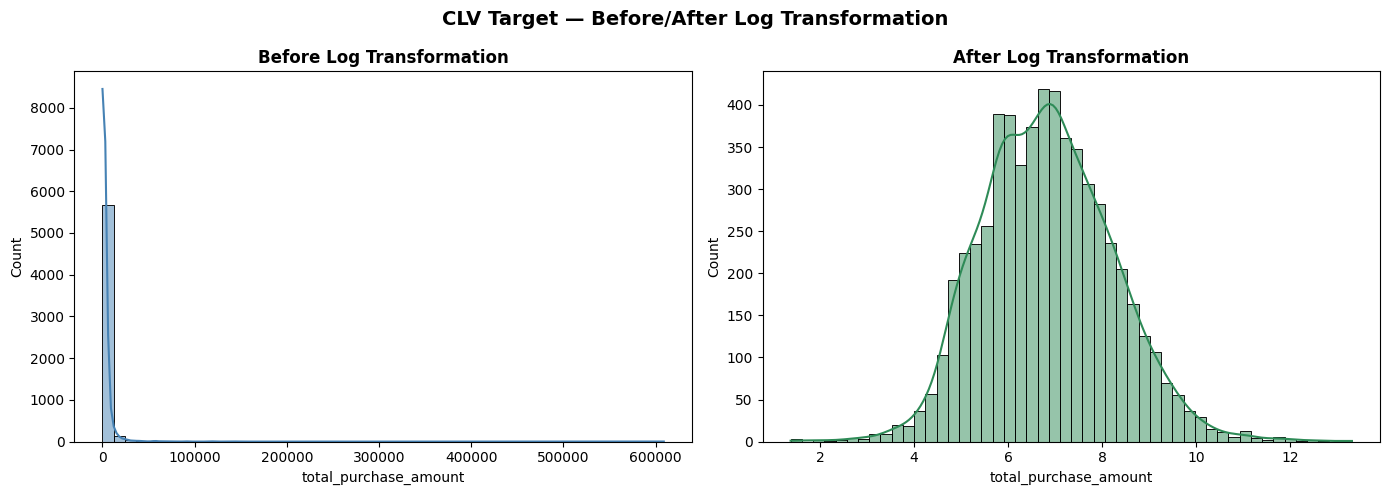

Mean CLV   : $3018.62
Median CLV : $898.91

99th Percentile: $29730.42
Users before   : 5,878
Users after    : 5,819


In [14]:
# 5 — CLV Distribution + Outlier Removal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CLV Target — Before/After Log Transformation',
             fontsize=14, fontweight='bold')

sns.histplot(hybrid_df['total_purchase_amount'], kde=True,
             color='steelblue', bins=50, ax=axes[0])
axes[0].set_title('Before Log Transformation', fontweight='bold')

sns.histplot(np.log1p(hybrid_df['total_purchase_amount']), kde=True,
             color='seagreen', bins=50, ax=axes[1])
axes[1].set_title('After Log Transformation', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean CLV   : ${hybrid_df['total_purchase_amount'].mean():.2f}")
print(f"Median CLV : ${hybrid_df['total_purchase_amount'].median():.2f}")

# Outlier removal
threshold = hybrid_df['total_purchase_amount'].quantile(0.99)
print(f"\n99th Percentile: ${threshold:.2f}")
print(f"Users before   : {len(hybrid_df):,}")
hybrid_df = hybrid_df[hybrid_df['total_purchase_amount'] <= threshold].copy()
print(f"Users after    : {len(hybrid_df):,}")

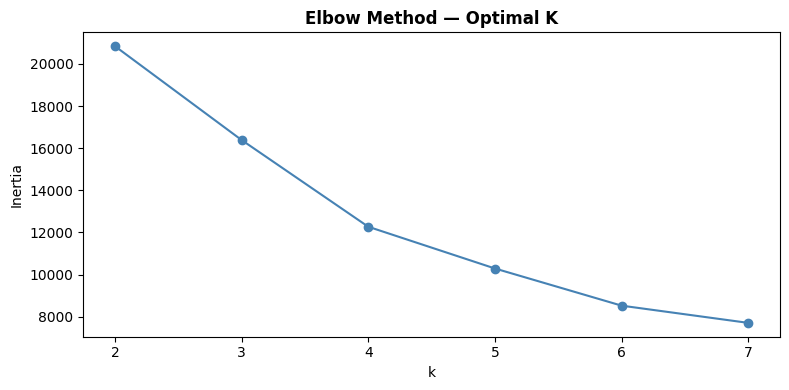


Clustering complete.
customer_segment
0    3230
1    1971
2       2
3     616
Name: count, dtype: int64

=== Cluster Profile ===
                  num_purchases  avg_order_value  total_items  recency_days  \
customer_segment                                                              
0                          4.74            29.04       934.87         75.10   
1                          2.03            35.37       354.49        463.44   
2                          1.50          8955.83         1.50        628.50   
3                         20.89            28.52      5681.57         37.91   

                  category_diversity  total_purchase_amount  
customer_segment                                             
0                              68.95                1603.17  
1                              32.80                 646.13  
2                               1.00               12434.92  
3                             274.10                9090.43  


In [15]:
# 6 — K-Means Segmentation

cluster_features = ['num_purchases', 'avg_order_value',
                    'total_items', 'recency_days', 'category_diversity']

X_cluster        = hybrid_df[cluster_features].copy()
scaler_cluster   = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

# Elbow method
inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K', fontweight='bold')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Apply k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
hybrid_df['customer_segment'] = kmeans.fit_predict(X_scaled_cluster)

print("\nClustering complete.")
print(hybrid_df['customer_segment'].value_counts().sort_index())
print("\n=== Cluster Profile ===")
print(hybrid_df.groupby('customer_segment')[
    cluster_features + ['total_purchase_amount']].mean().round(2))

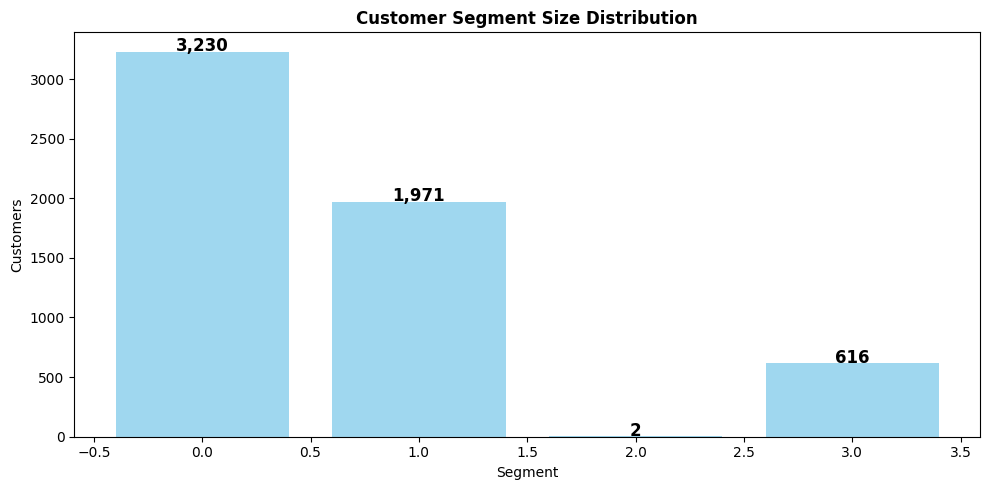

In [16]:
# 7 — Segment Size Chart

plt.figure(figsize=(10, 5))
seg_counts = hybrid_df['customer_segment'].value_counts().sort_index()
bars = plt.bar(seg_counts.index, seg_counts.values, color='skyblue', alpha=0.8)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 5,
             f'{h:,}', ha='center', fontweight='bold', fontsize=12)
plt.title('Customer Segment Size Distribution', fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

In [17]:
# 8 — Segmented XGBoost

feature_columns = ['num_purchases', 'avg_order_value', 'total_items',
                   'recency_days', 'first_purchase_gap_days',
                   'sessions_per_user', 'category_diversity',
                   'conversion_rate', 'avg_items_per_order']

segment_metrics = {}

print("=" * 50)
print("Hybrid XGBoost — Segment-wise CLV Modelling")
print("=" * 50)

for seg in sorted(hybrid_df['customer_segment'].unique()):
    df_seg = hybrid_df[hybrid_df['customer_segment'] == seg].copy()
    if len(df_seg) < 50:
        print(f"\nSegment {seg} skipped")
        continue

    X = df_seg[feature_columns].copy()
    y = np.log1p(df_seg['total_purchase_amount'])

    scaler_seg = MinMaxScaler()
    X_scaled   = pd.DataFrame(scaler_seg.fit_transform(X),
                               columns=feature_columns)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                              learning_rate=0.1, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    y_pred_orig = np.expm1(y_pred)  
    y_te_orig   = np.expm1(y_te)


    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
    mae  = mean_absolute_error(y_te_orig, y_pred_orig)
    r2   = r2_score(y_te, y_pred)  

    segment_metrics[seg] = {
        'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'model': model, 'X_test': X_te,
        'y_test': y_te, 'n_users': len(df_seg)
    }

    print(f"\nSegment {seg} ({len(df_seg):,} users)")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

print("\n" + "=" * 50)
avg_rmse = np.mean([v['RMSE'] for v in segment_metrics.values()])
avg_mae  = np.mean([v['MAE']  for v in segment_metrics.values()])
avg_r2   = np.mean([v['R2']   for v in segment_metrics.values()])
print(f"Average — RMSE: {avg_rmse:.4f} | MAE: {avg_mae:.4f} | R²: {avg_r2:.4f}")

Hybrid XGBoost — Segment-wise CLV Modelling

Segment 0 (3,230 users)
  RMSE : 635.8436
  MAE  : 262.7203
  R²   : 0.9608

Segment 1 (1,971 users)
  RMSE : 883.5934
  MAE  : 152.8654
  R²   : 0.9614

Segment 2 skipped

Segment 3 (616 users)
  RMSE : 3035.7345
  MAE  : 1836.6709
  R²   : 0.7563

Average — RMSE: 1518.3905 | MAE: 750.7522 | R²: 0.8928


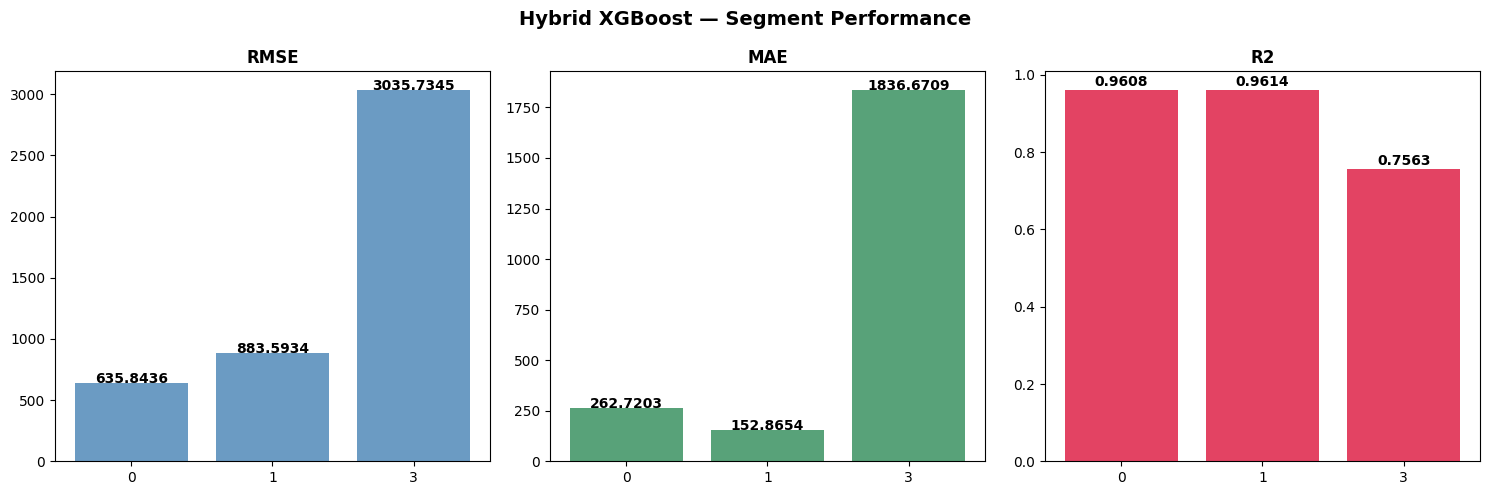


=== Segment Performance Summary ===
Segment    R2         RMSE       MAE       
----------------------------------------
0          0.9608     635.8436   262.7203  
1          0.9614     883.5934   152.8654  
3          0.7563     3035.7345  1836.6709 


In [18]:
# 9 — Segment Performance Visualisation

seg_df = pd.DataFrame({
    seg: {k: v for k, v in vals.items() if k in ['RMSE','MAE','R2']}
    for seg, vals in segment_metrics.items()
}).T.reset_index()
seg_df.rename(columns={'index': 'Segment'}, inplace=True)
seg_df['Segment'] = seg_df['Segment'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Hybrid XGBoost — Segment Performance',
             fontsize=14, fontweight='bold')

for i, (metric, color) in enumerate(zip(
        ['RMSE','MAE','R2'], ['steelblue','seagreen','crimson'])):
    axes[i].bar(seg_df['Segment'], seg_df[metric].astype(float),
                color=color, alpha=0.8)
    axes[i].set_title(metric, fontweight='bold')
    for j, val in enumerate(seg_df[metric].astype(float)):
        axes[i].text(j, val + 0.01, f'{val:.4f}',
                     ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Segment Performance Summary ===")
print(f"{'Segment':<10} {'R2':<10} {'RMSE':<10} {'MAE':<10}")
print("-" * 40)
for _, row in seg_df.iterrows():
    print(f"{row['Segment']:<10} {float(row['R2']):<10.4f} "
          f"{float(row['RMSE']):<10.4f} {float(row['MAE']):<10.4f}")

In [19]:
#  10 — Category-Based XGBoost

df_category = hybrid_df.dropna(subset=['top_category'])
print(f"Samples: {len(df_category):,} | "
      f"Categories: {df_category['top_category'].nunique()}")

category_results = []
skipped = 0

for cat in df_category['top_category'].unique():
    df_cat = df_category[df_category['top_category'] == cat].copy()
    if len(df_cat) < 50:
        skipped += 1
        continue

    X = df_cat[feature_columns].copy()
    y = np.log1p(df_cat['total_purchase_amount'])

    scaler_cat = MinMaxScaler()
    X_scaled   = pd.DataFrame(scaler_cat.fit_transform(X),
                               columns=feature_columns)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                              learning_rate=0.1, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    y_pred_orig = np.expm1(y_pred)
    y_te_orig   = np.expm1(y_te)       

    category_results.append({
        'Category': cat,
        'Samples' : len(df_cat),
        'RMSE'    : np.sqrt(mean_squared_error(y_te_orig, y_pred_orig)),
        'MAE'     : mean_absolute_error(y_te_orig, y_pred_orig),
        'R2'      : r2_score(y_te, y_pred)
    })

category_results_df = pd.DataFrame(category_results)
total_cats   = df_category['top_category'].nunique()
modeled_cats = len(category_results_df)

print("\n" + "=" * 60)
print("CATEGORY MODELING SUMMARY")
print("=" * 60)
print(f"Total categories         : {total_cats}")
print(f"Categories modeled (≥50) : {modeled_cats}")
print(f"Categories skipped       : {skipped}")
print(f"Modeling success rate    : {modeled_cats/total_cats*100:.1f}%")
print(f"Average RMSE             : {category_results_df['RMSE'].mean():.4f}")
print(f"Average R²               : {category_results_df['R2'].mean():.4f}")
print("=" * 60)

Samples: 5,819 | Categories: 1412

CATEGORY MODELING SUMMARY
Total categories         : 1412
Categories modeled (≥50) : 7
Categories skipped       : 1405
Modeling success rate    : 0.5%
Average RMSE             : 1782.7412
Average R²               : 0.9245


TOP 10 CATEGORY-SPECIFIC CLV MODELS BY RMSE
Rank  Category             Samples    RMSE       R²        
------------------------------------------------------------
1     85099B               92         573.3667   0.9108    
2     85123A               198        814.8338   0.9508    
3     20914                72         1032.0642  0.9395    
4     POST                 166        1124.7544  0.9281    
5     21034                112        1251.2188  0.8740    
6     84879                83         3821.1523  0.9220    
7     22423                85         3861.7982  0.9466    


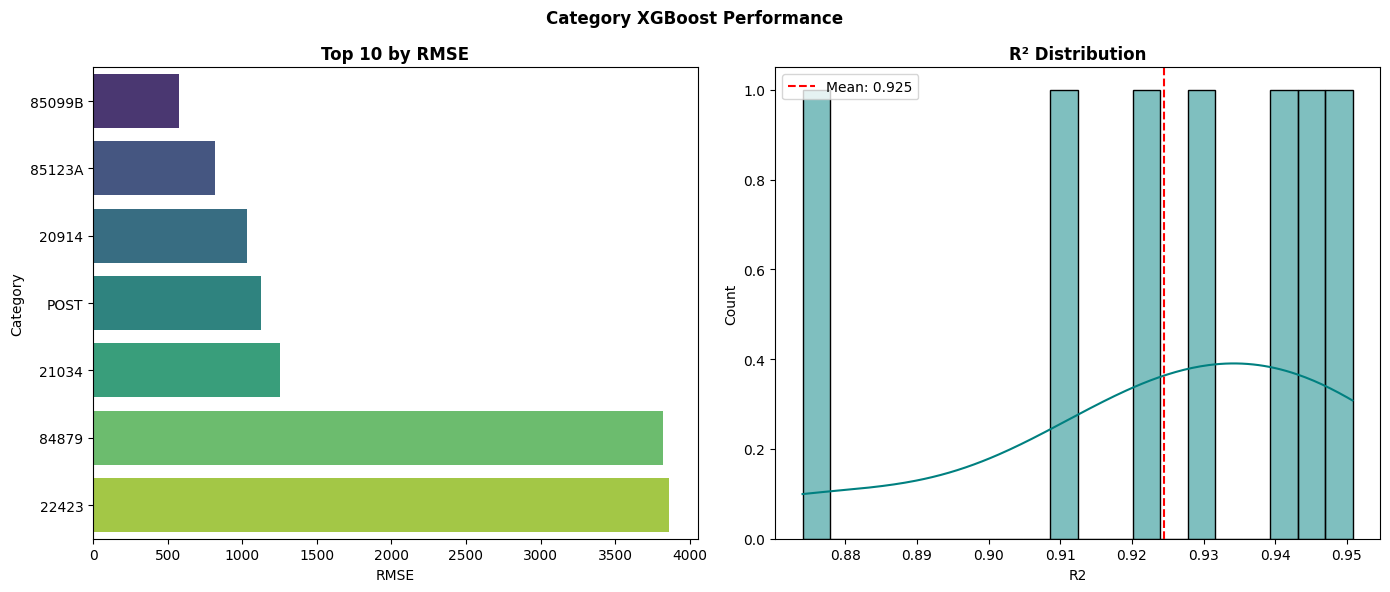

In [20]:
#  11 — Top 10 Categories + Visualisation

top_10 = category_results_df.sort_values('RMSE').head(10)

print("=" * 60)
print("TOP 10 CATEGORY-SPECIFIC CLV MODELS BY RMSE")
print("=" * 60)
print(f"{'Rank':<5} {'Category':<20} {'Samples':<10} "
      f"{'RMSE':<10} {'R²':<10}")
print("-" * 60)
for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"{i:<5} {row['Category']:<20} {int(row['Samples']):<10} "
          f"{row['RMSE']:<10.4f} {row['R2']:<10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Category XGBoost Performance', fontweight='bold')

sns.barplot(x='RMSE', y='Category', data=top_10,
            palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 by RMSE', fontweight='bold')

sns.histplot(category_results_df['R2'], bins=20,
             kde=True, color='teal', ax=axes[1])
axes[1].axvline(category_results_df['R2'].mean(),
                color='red', linestyle='--',
                label=f"Mean: {category_results_df['R2'].mean():.3f}")
axes[1].set_title('R² Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# 12 — Session Feature Engineering

print("Creating session-level features...")

session_df = df.groupby(['Customer ID', 'Invoice']).agg(
    session_revenue       = ('Revenue',     'sum'),
    items_in_session      = ('Quantity',    'sum'),
    unique_products       = ('StockCode',   'nunique'),
    session_date          = ('InvoiceDate', 'min'),
    session_duration_mins = ('InvoiceDate',
                             lambda x: (x.max()-x.min()).seconds/60)
).reset_index()

session_df['is_purchase'] = (session_df['session_revenue'] > 0).astype(int)

print(f"Sessions created : {len(session_df):,}")
print(f"Unique customers : {session_df['Customer ID'].nunique():,}")

Creating session-level features...
Sessions created : 36,969
Unique customers : 5,878


In [22]:
# 13 — Session-Based XGBoost (Cold-Start)

sess_features_agg = session_df.groupby('Customer ID').agg(
    total_items_sess      = ('items_in_session', 'sum'),
    avg_items_per_session = ('items_in_session', 'mean'),
    unique_products_sess  = ('unique_products',  'sum'),
    total_sessions        = ('Invoice',          'nunique'),
    avg_session_duration  = ('session_duration_mins', 'mean'),
    purchase_sessions     = ('is_purchase',      'sum')
).reset_index()

sess_model_df = sess_features_agg.merge(
    hybrid_df[['Customer ID', 'total_purchase_amount']],
    on='Customer ID', how='inner')

print(f"Session dataset  : {len(sess_model_df):,} users")

sess_cols = ['total_items_sess', 'avg_items_per_session',
             'unique_products_sess', 'total_sessions',
             'avg_session_duration', 'purchase_sessions']

X_sess        = sess_model_df[sess_cols].fillna(0)
y_sess        = np.log1p(sess_model_df['total_purchase_amount'])
scaler_sess   = MinMaxScaler()
X_sess_scaled = pd.DataFrame(scaler_sess.fit_transform(X_sess),
                               columns=sess_cols)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sess_scaled, y_sess, test_size=0.2, random_state=42)

sess_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                              learning_rate=0.1, random_state=42)
sess_xgb.fit(X_tr, y_tr)
y_pred_sess = sess_xgb.predict(X_te)

y_pred_orig = np.expm1(y_pred_sess)
y_te_orig   = np.expm1(y_te)

rmse_sess = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
mae_sess  = mean_absolute_error(y_te_orig, y_pred_orig)
r2_sess   = r2_score(y_te, y_pred_sess)

print("\n── Session-Based XGBoost (Cold-Start) ───────────")
print(f"  RMSE : {rmse_sess:.4f}")
print(f"  MAE  : {mae_sess:.4f}")
print(f"  R²   : {r2_sess:.4f}")

Session dataset  : 5,819 users

── Session-Based XGBoost (Cold-Start) ───────────
  RMSE : 1196.0890
  MAE  : 523.9942
  R²   : 0.9114


In [23]:
# 14 — Sequential LSTM Prep

MAX_SESSIONS = 10
SEQ_FEATURES = ['items_in_session', 'unique_products',
                'is_purchase', 'session_duration_mins']

session_df_sorted = session_df.sort_values(['Customer ID', 'session_date'])
clv_lookup        = hybrid_df[['Customer ID', 'total_purchase_amount']]
users_with_clv    = clv_lookup['Customer ID'].values

print("Building session sequences...")
sequences, targets, users_seq = [], [], []

for cust_id in users_with_clv:
    cust_sess = session_df_sorted[
        session_df_sorted['Customer ID'] == cust_id][SEQ_FEATURES].values

    if len(cust_sess) >= MAX_SESSIONS:
        seq = cust_sess[-MAX_SESSIONS:]
    else:
        pad = np.zeros((MAX_SESSIONS - len(cust_sess), len(SEQ_FEATURES)))
        seq = np.vstack([pad, cust_sess])

    clv = clv_lookup[clv_lookup['Customer ID'] == cust_id][
        'total_purchase_amount'].values[0]

    sequences.append(seq)
    targets.append(np.log1p(clv))
    users_seq.append(cust_id)

X_seq = np.array(sequences, dtype=np.float32)
y_seq = np.array(targets,   dtype=np.float32)

print(f"Sequence array : {X_seq.shape}")
print(f"Target array   : {y_seq.shape}")

Building session sequences...
Sequence array : (5819, 10, 4)
Target array   : (5819,)


In [24]:
# 15 — Sequential LSTM Training

# Normalize
X_seq_flat = X_seq.reshape(-1, len(SEQ_FEATURES))
scaler_seq  = MinMaxScaler()
X_seq_norm  = scaler_seq.fit_transform(X_seq_flat).reshape(X_seq.shape)

# Split
n       = len(X_seq_norm)
train_i = int(n * 0.8)
X_tr_s  = X_seq_norm[:train_i];  X_te_s = X_seq_norm[train_i:]
y_tr_s  = y_seq[:train_i];       y_te_s = y_seq[train_i:]

# Model
lstm_model = tf.keras.Sequential([
    Input(shape=(MAX_SESSIONS, len(SEQ_FEATURES)), name='seq_input'),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
], name='Sequential_LSTM')

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

history = lstm_model.fit(
    X_tr_s, y_tr_s,
    validation_split=0.2,
    epochs=50, batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True)],
    verbose=1
)

y_lstm_pred = lstm_model.predict(X_te_s).flatten()
y_pred_orig = np.expm1(y_lstm_pred)
y_te_orig   = np.expm1(y_te_s)

rmse_lstm = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
mae_lstm  = mean_absolute_error(y_te_orig, y_pred_orig)
r2_lstm   = r2_score(y_te_s, y_lstm_pred)

print(f"\n── Sequential LSTM ───────────")
print(f"  RMSE : {rmse_lstm:.4f}")
print(f"  MAE  : {mae_lstm:.4f}")
print(f"  R²   : {r2_lstm:.4f}")

Model: "Sequential_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 47.0055 - val_loss: 42.8885
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 37.6796 - val_loss: 24.0742
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.1658 - val_loss: 3.2931
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.4553 - val_loss: 1.1825
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.4282 - val_loss: 1.0783
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0837 - val_loss: 0.8579
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8140 - val_loss: 0.6063
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6424 - val_loss: 0.5431
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6037 - val_loss: 0.5553
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6027 - val_loss: 0.5393
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6013 - val_loss: 0.5513
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss:

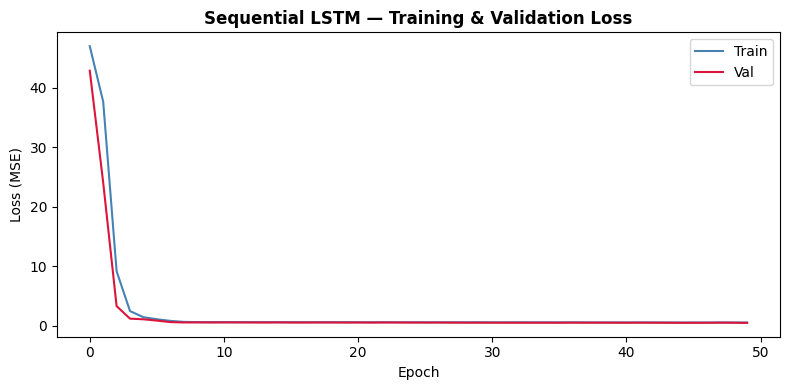

In [25]:
# 16 — LSTM Loss Plot

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train', color='steelblue')
plt.plot(history.history['val_loss'], label='Val',   color='crimson')
plt.title('Sequential LSTM — Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# 17 — Hybrid LSTM Feature Fusion

static_cols = ['avg_order_value', 'num_purchases', 'total_items',
               'recency_days', 'first_purchase_gap_days',
               'category_diversity', 'conversion_rate',
               'avg_items_per_order']

hybrid_seq_df = (hybrid_df[hybrid_df['Customer ID'].isin(users_seq)]
                 .set_index('Customer ID')
                 .loc[users_seq]
                 .reset_index())

X_static      = hybrid_seq_df[static_cols].fillna(0).values.astype(np.float32)
scaler_static = MinMaxScaler()
X_static_norm = scaler_static.fit_transform(X_static)

print(f"Sequence input : {X_seq_norm.shape}")
print(f"Static input   : {X_static_norm.shape}")

X_seq_tr_h  = X_seq_norm[:train_i];  X_seq_te_h  = X_seq_norm[train_i:]
X_static_tr = X_static_norm[:train_i]; X_static_te = X_static_norm[train_i:]

# Build model
seq_in   = Input(shape=(MAX_SESSIONS, len(SEQ_FEATURES)), name='seq_input')
lstm_out = LSTM(64)(seq_in)
lstm_out = Dense(32, activation='relu')(lstm_out)

stat_in  = Input(shape=(len(static_cols),), name='static_input')
stat_out = Dense(32, activation='relu')(stat_in)
stat_out = Dense(16, activation='relu')(stat_out)

merged   = Concatenate()([lstm_out, stat_out])
merged   = Dense(32, activation='relu')(merged)
merged   = Dropout(0.2)(merged)
output   = Dense(1)(merged)

hybrid_lstm = Model(inputs=[seq_in, stat_in], outputs=output,
                    name='Hybrid_LSTM_FeatureFusion')
hybrid_lstm.compile(optimizer='adam', loss='mse')
hybrid_lstm.summary()

history_h = hybrid_lstm.fit(
    [X_seq_tr_h, X_static_tr], y_tr_s,
    validation_split=0.2,
    epochs=50, batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True)],
    verbose=1
)

y_hybrid_pred = hybrid_lstm.predict([X_seq_te_h, X_static_te]).flatten()
y_pred_orig = np.expm1(y_hybrid_pred)
y_te_orig   = np.expm1(y_te_s)

rmse_hybrid = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
mae_hybrid  = mean_absolute_error(y_te_orig, y_pred_orig)
r2_hybrid   = r2_score(y_te_s, y_hybrid_pred)

print(f"\n── Hybrid LSTM Fusion ───────────")
print(f"  RMSE : {rmse_hybrid:.4f}")
print(f"  MAE  : {mae_hybrid:.4f}")
print(f"  R²   : {r2_hybrid:.4f}")

Sequence input : (5819, 10, 4)
Static input   : (5819, 8)


Model: "Hybrid_LSTM_FeatureFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     17,664 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        288 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,161 (86.57 KB)

 Trainable params: 22,161 (86.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 45.9153 - val_loss: 41.8096
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 36.8023 - val_loss: 23.1892
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 10.2044 - val_loss: 3.0401
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.8942 - val_loss: 1.6818
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.0766 - val_loss: 0.6689
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.4231 - val_loss: 0.6479
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2193 - val_loss: 0.5221
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.1731 - val_loss: 0.5184
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.0891 - val_loss: 0.5248
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.9487 - val_loss: 0.5060
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.8758 - val_loss: 0.4900
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss

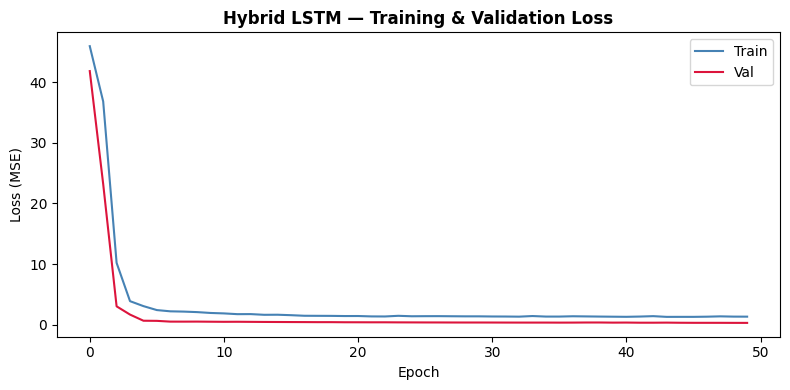

In [27]:
# 18 — Hybrid LSTM Loss Plot

plt.figure(figsize=(8, 4))
plt.plot(history_h.history['loss'],     label='Train', color='steelblue')
plt.plot(history_h.history['val_loss'], label='Val',   color='crimson')
plt.title('Hybrid LSTM — Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# 19 — Final Benchmark All Models

benchmark_metrics = {
    'Mean Baseline'     : {
        'RMSE': np.sqrt(mean_squared_error(
                    y_seq[train_i:],
                    np.full(len(y_seq)-train_i, y_seq[:train_i].mean()))),
        'MAE' : mean_absolute_error(
                    y_seq[train_i:],
                    np.full(len(y_seq)-train_i, y_seq[:train_i].mean())),
        'R2'  : r2_score(
                    y_seq[train_i:],
                    np.full(len(y_seq)-train_i, y_seq[:train_i].mean()))
    },
    'Segmented XGBoost' : {
        'RMSE': np.mean([v['RMSE'] for v in segment_metrics.values()]),
        'MAE' : np.mean([v['MAE']  for v in segment_metrics.values()]),
        'R2'  : np.mean([v['R2']   for v in segment_metrics.values()])
    },
    'Category XGBoost'  : {
        'RMSE': category_results_df['RMSE'].mean(),
        'MAE' : category_results_df['MAE'].mean(),
        'R2'  : category_results_df['R2'].mean()
    },
    'Session XGBoost'   : {'RMSE': rmse_sess,   'MAE': mae_sess,   'R2': r2_sess},
    'Sequential LSTM'   : {'RMSE': rmse_lstm,   'MAE': mae_lstm,   'R2': r2_lstm},
    'Hybrid LSTM Fusion': {'RMSE': rmse_hybrid, 'MAE': mae_hybrid, 'R2': r2_hybrid}
}

benchmark_df = pd.DataFrame(benchmark_metrics).T.astype(float)

print("\n" + "=" * 55)
print("Final Benchmark — All Models")
print("=" * 55)
print(f"{'Model':<22} {'RMSE':<10} {'MAE':<10} {'R2':<10}")
print("-" * 55)
for name, row in benchmark_df.iterrows():
    print(f"{name:<22} {row['RMSE']:<10.4f} "
          f"{row['MAE']:<10.4f} {row['R2']:<10.4f}")
print("=" * 55)


Final Benchmark — All Models
Model                  RMSE       MAE        R2        
-------------------------------------------------------
Mean Baseline          1.3250     1.0823     -0.0200   
Segmented XGBoost      1518.3905  750.7522   0.8928    
Category XGBoost       1782.7412  836.3703   0.9245    
Session XGBoost        1196.0890  523.9942   0.9114    
Sequential LSTM        2384.8174  935.5311   0.7137    
Hybrid LSTM Fusion     2959.6015  832.4465   0.7946    


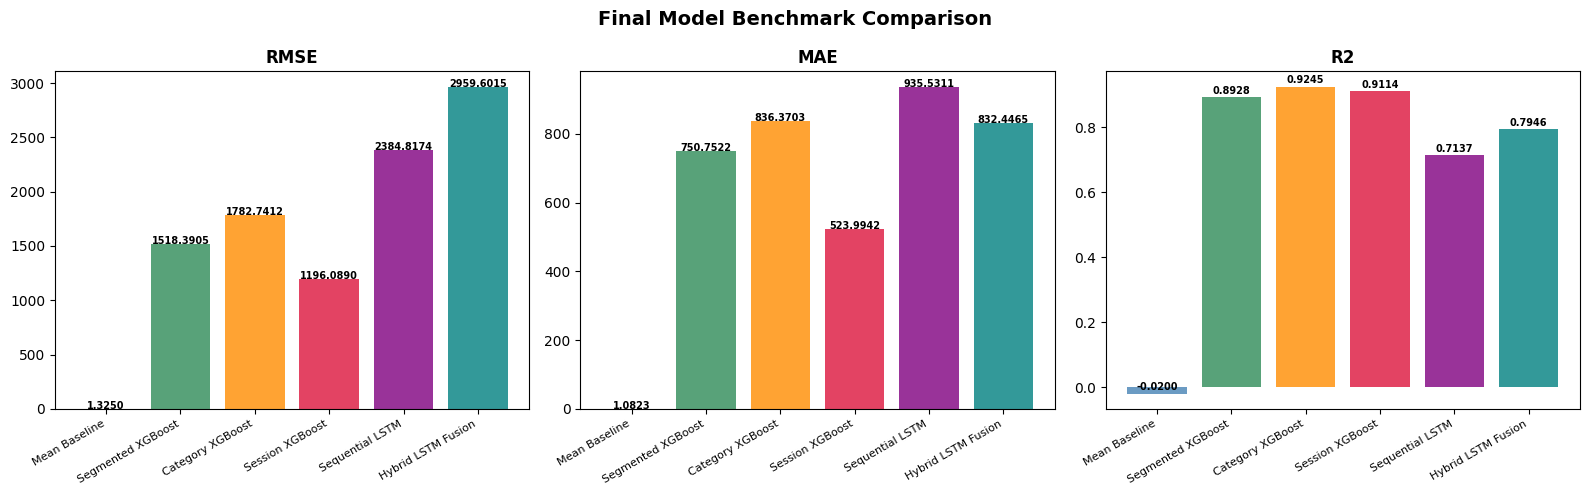

In [29]:
# 20 — Final Benchmark Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Final Model Benchmark Comparison',
             fontsize=14, fontweight='bold')

colors = ['steelblue','seagreen','darkorange',
          'crimson','purple','teal']

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    values = benchmark_df[metric].astype(float)
    axes[i].bar(range(len(values)), values,
                color=colors[:len(values)], alpha=0.8)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(benchmark_df.index,
                             rotation=30, ha='right', fontsize=8)
    for j, val in enumerate(values):
        axes[i].text(j, val + 0.01, f'{val:.4f}',
                     ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

SHAP Analysis per Segment


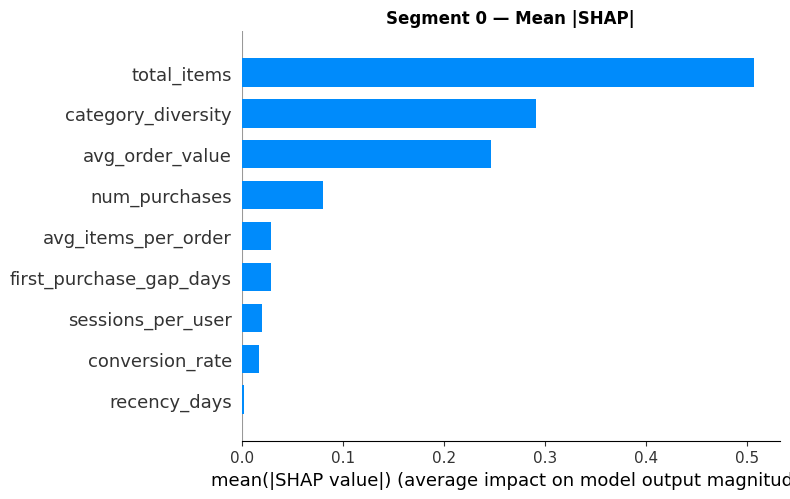

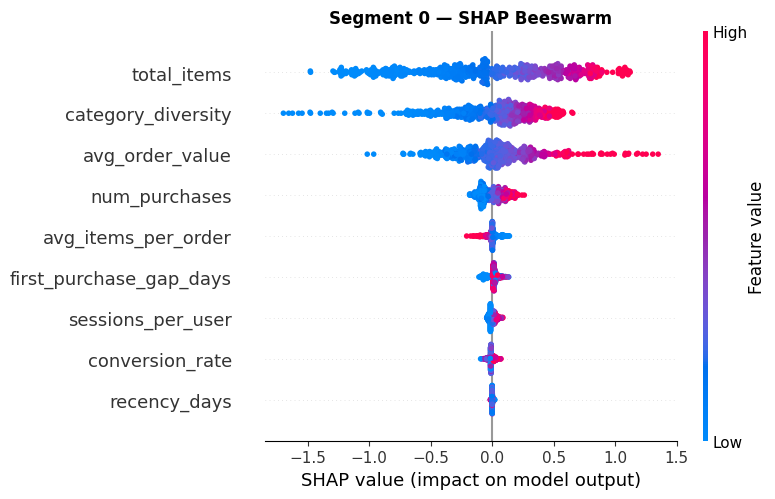

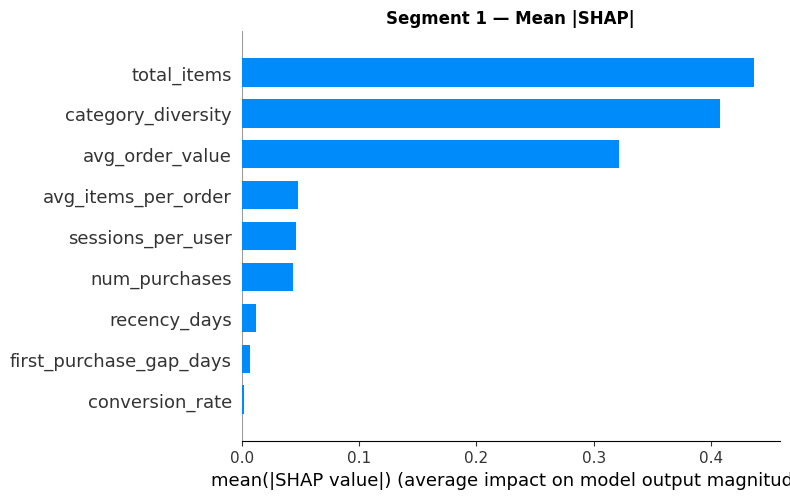

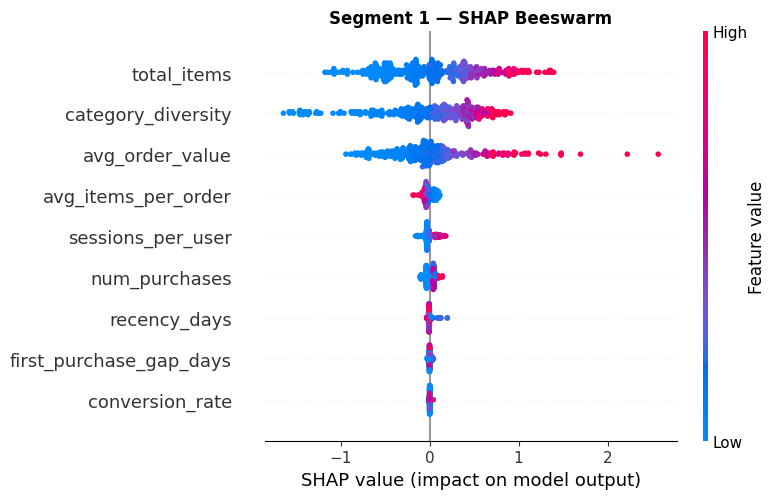

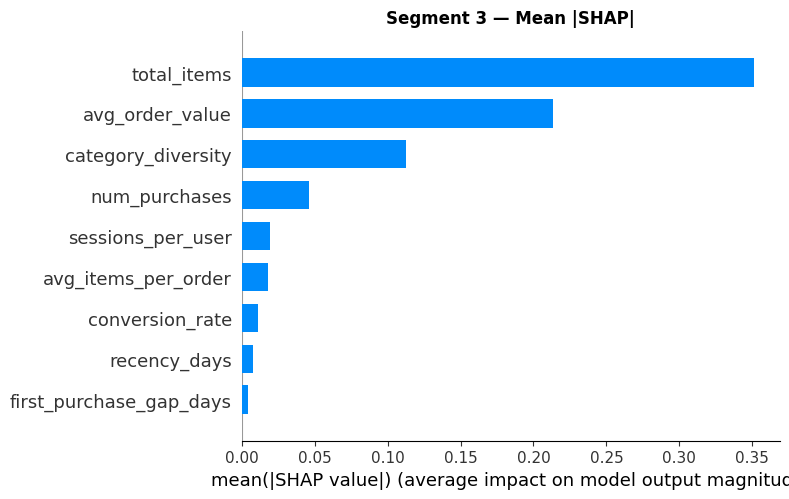

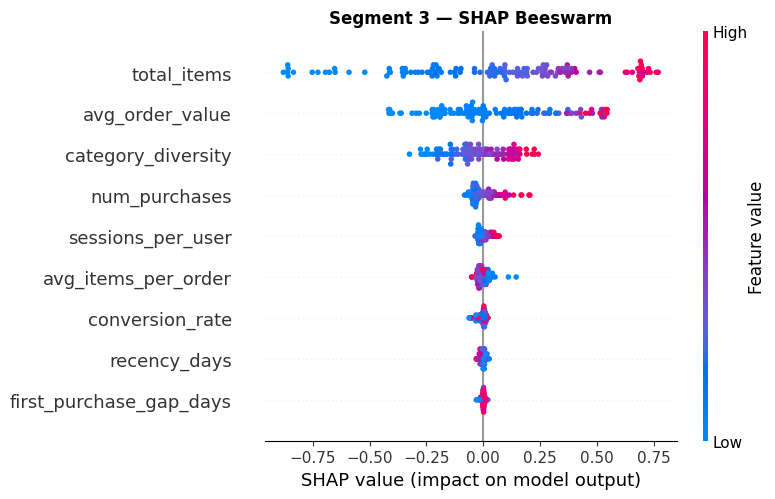

In [30]:
#  21 — SHAP per Segment

print("=" * 50)
print("SHAP Analysis per Segment")
print("=" * 50)

for seg, vals in segment_metrics.items():
    model = vals['model']
    X_te  = vals['X_test']

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_te)

    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_te, plot_type='bar', show=False)
    plt.title(f'Segment {seg} — Mean |SHAP|', fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_te, show=False)
    plt.title(f'Segment {seg} — SHAP Beeswarm', fontweight='bold')
    plt.tight_layout()
    plt.show()